# Notebook 17: Experience Replay & Prioritized ER

**Series:** Reinforcement Learning Basics (17/20)

---

## 1. Uniform Experience Replay

Store transitions $(s, a, r, s', done)$ in a circular buffer $\mathcal{D}$ of fixed capacity $N$.

**Sample uniformly:** Each transition equally likely to be sampled.

**Benefits:**
- Breaks temporal correlations between consecutive samples
- Each transition can be reused many times (sample efficiency)
- Stabilizes training (reduces non-stationarity)

## 2. Prioritized Experience Replay (PER)

**Idea:** Some transitions are more "surprising" — sample them more often.

**Priority:** $p_i = |\delta_i| + \epsilon$ where $\delta_i$ is TD error

**Sampling probability:**
$$P(i) = \frac{p_i^\alpha}{\sum_k p_k^\alpha}$$

- $\alpha = 0$: uniform sampling
- $\alpha = 1$: fully prioritized

### Importance Sampling Correction

Biased sampling → biased gradient → need correction:
$$w_i = \left(\frac{1}{N \cdot P(i)}\right)^\beta$$

$\beta$ is annealed from some initial value to 1 over training.

### SumTree Data Structure

Efficient $O(\log N)$ sampling using a binary tree where each leaf stores a priority and internal nodes store the sum of their children.

## 3. Hindsight Experience Replay (HER)

For **sparse reward** environments:
- Episode failed to reach goal $g$
- Relabel: pretend the achieved state was the goal
- Failed experience → successful experience for a different goal

**Strategies:** final, future, episode, random

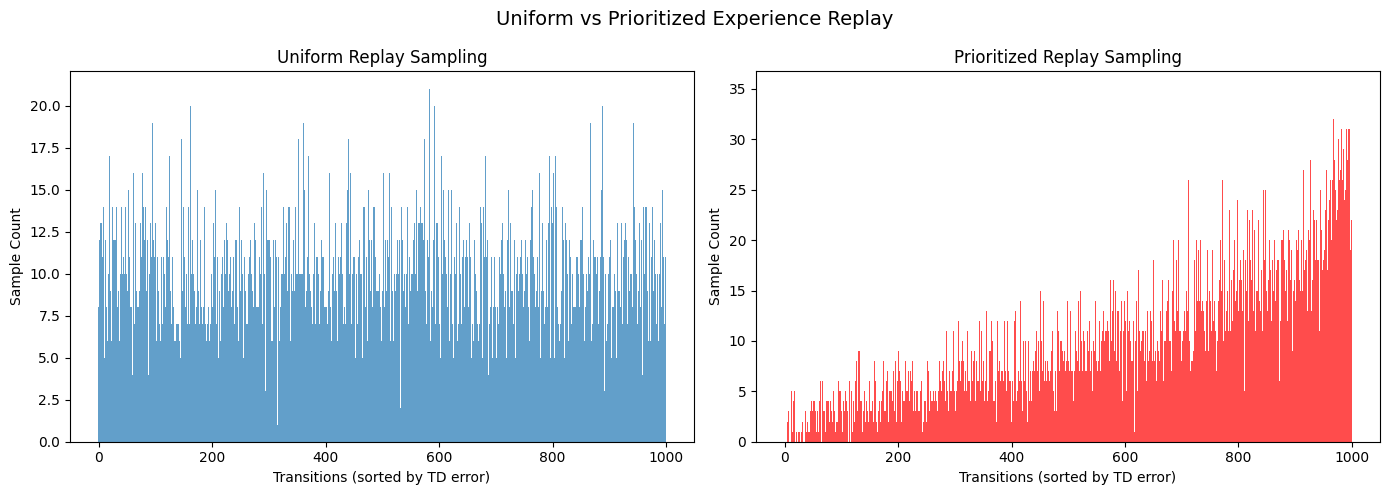

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# SumTree for Prioritized Replay
# ============================================
class SumTree:
    def __init__(self, capacity):
        self.capacity = capacity
        self.tree = np.zeros(2 * capacity - 1)
        self.data = [None] * capacity
        self.write = 0
        self.n_entries = 0

    def _propagate(self, idx, change):
        parent = (idx - 1) // 2
        self.tree[parent] += change
        if parent != 0:
            self._propagate(parent, change)

    def _retrieve(self, idx, s):
        left = 2 * idx + 1
        right = left + 1
        if left >= len(self.tree):
            return idx
        if s <= self.tree[left]:
            return self._retrieve(left, s)
        else:
            return self._retrieve(right, s - self.tree[left])

    def total(self):
        return self.tree[0]

    def add(self, priority, data):
        idx = self.write + self.capacity - 1
        self.data[self.write] = data
        self.update(idx, priority)
        self.write = (self.write + 1) % self.capacity
        if self.n_entries < self.capacity:
            self.n_entries += 1

    def update(self, idx, priority):
        change = priority - self.tree[idx]
        self.tree[idx] = priority
        self._propagate(idx, change)

    def get(self, s):
        idx = self._retrieve(0, s)
        data_idx = idx - self.capacity + 1
        return idx, self.tree[idx], self.data[data_idx]

class PrioritizedReplayBuffer:
    def __init__(self, capacity=10000, alpha=0.6, beta=0.4, beta_increment=0.001):
        self.tree = SumTree(capacity)
        self.alpha = alpha
        self.beta = beta
        self.beta_increment = beta_increment
        self.epsilon = 0.01
        self.max_priority = 1.0

    def push(self, state, action, reward, next_state, done):
        self.tree.add(self.max_priority ** self.alpha, (state, action, reward, next_state, done))

    def sample(self, batch_size):
        indices, priorities, samples = [], [], []
        segment = self.tree.total() / batch_size

        self.beta = min(1.0, self.beta + self.beta_increment)

        for i in range(batch_size):
            s = np.random.uniform(segment * i, segment * (i + 1))
            idx, priority, data = self.tree.get(s)
            if data is not None:
                indices.append(idx)
                priorities.append(priority)
                samples.append(data)

        probs = np.array(priorities) / self.tree.total()
        weights = (self.tree.n_entries * probs) ** (-self.beta)
        weights /= weights.max()

        s, a, r, sn, d = zip(*samples)
        return np.array(s), np.array(a), np.array(r), np.array(sn), np.array(d), indices, weights

    def update_priorities(self, indices, td_errors):
        for idx, td_error in zip(indices, td_errors):
            priority = (abs(td_error) + self.epsilon) ** self.alpha
            self.tree.update(idx, priority)
            self.max_priority = max(self.max_priority, priority)

    def __len__(self):
        return self.tree.n_entries

# Demo: Compare sampling distributions
buf_uniform = []
buf_per = PrioritizedReplayBuffer(capacity=1000)

# Add 1000 transitions with varying TD errors
td_errors = np.random.exponential(1.0, 1000)
for i in range(1000):
    data = (np.zeros(4), 0, 0, np.zeros(4), False)
    buf_uniform.append(data)
    buf_per.push(*data)
    buf_per.update_priorities([i + 999], [td_errors[i]])

# Sample and see distribution
n_samples = 10000
uniform_counts = np.zeros(1000)
per_counts = np.zeros(1000)

for _ in range(n_samples):
    idx = np.random.randint(1000)
    uniform_counts[idx] += 1

# For PER, track which indices get sampled
for _ in range(n_samples // 32):
    _, _, _, _, _, indices, _ = buf_per.sample(32)
    for idx in indices:
        data_idx = idx - 999
        if 0 <= data_idx < 1000:
            per_counts[data_idx] += 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sorted_idx = np.argsort(td_errors)
axes[0].bar(range(1000), uniform_counts[sorted_idx], alpha=0.7, width=1)
axes[0].set_title('Uniform Replay Sampling')
axes[0].set_xlabel('Transitions (sorted by TD error)')
axes[0].set_ylabel('Sample Count')

axes[1].bar(range(1000), per_counts[sorted_idx], alpha=0.7, width=1, color='red')
axes[1].set_title('Prioritized Replay Sampling')
axes[1].set_xlabel('Transitions (sorted by TD error)')
axes[1].set_ylabel('Sample Count')

plt.suptitle('Uniform vs Prioritized Experience Replay', fontsize=14)
plt.tight_layout()
plt.show()

## Summary

| Method | Sampling | Correction |
|--------|----------|-----------|
| **Uniform ER** | $P(i) = 1/N$ | None needed |
| **PER** | $P(i) = p_i^\alpha / \sum p_k^\alpha$ | IS weights $w_i = (NP(i))^{-\beta}$ |
| **HER** | Relabel goals | None |

**Next:** Notebook 18 — Exploration vs Exploitation